# Visualize the CaP Ctrl-G run

Joins the **input prompts** (`demo/prompts_v3_indexed.jsonl`) with the **model outputs** (`demo/ctrlg_run/outputs_llama3_ctrlg.jsonl`) on `id`, then renders:
- **§0 input prompts (v3)** — indexed objects + any v2→v3 rewrites
- prompt-side summary (difficulty, target predicate, expected `cap_operations`, object counts)
- output-side summary (pass rate, γ/β flag health)
- per-example table with the prompt *and* the generated code side-by-side
- failure drill-down with root-cause attribution from `FAILURE_ANALYSIS`

In [1]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import HTML, display
from pygments import highlight
from pygments.lexers import PythonLexer
from pygments.formatters import HtmlFormatter

PROMPTS_PATH = Path('demo/prompts_v3_indexed.jsonl')
OUTPUTS_PATH = Path('demo/ctrlg_run/outputs_llama3_ctrlg.jsonl')


def read_jsonl(p: Path) -> list[dict]:
    return [json.loads(line) for line in p.read_text().splitlines() if line.strip()]


prompts = pd.json_normalize(read_jsonl(PROMPTS_PATH))
outputs = pd.json_normalize(read_jsonl(OUTPUTS_PATH))
print(f'prompts: {len(prompts)} rows, outputs: {len(outputs)} rows')

# Join on id. Prefix prompt columns to avoid collisions on e.g. `query`.
prompt_cols = {c: f'prompt.{c}' for c in prompts.columns if c != 'id'}
df = outputs.merge(prompts.rename(columns=prompt_cols), on='id', how='left', validate='one_to_one')
print(f'joined df: {len(df)} rows (unmatched outputs: {int(df["prompt.query"].isna().sum())})')
df.head(3)

prompts: 45 rows, outputs: 45 rows
joined df: 45 rows (unmatched outputs: 0)


,id,query,model,run_type,timestamp,generated_code,overall_pass,error,context_objects,gamma_flags.syntactically_valid,...,prompt.source,prompt.source_identifier,prompt.task_name,prompt.objects,prompt.object_categories,prompt.target_predicate,prompt.query,prompt.cap_operations,prompt.difficulty,prompt.context
0,c001,move the plywoods to the designated area,dganochenko/llama-3-8b-chat,ctrlg,2026-04-15T20:22:43Z,"put_first_on_second('plywood', 'designated area')",False,None,[plywood],True,...,behavior/action_sequencing,bringing_in_wood_0_Benevolence_1_int_0_2021-09...,bringing in wood,"[plywood, plywood, plywood]","[plywood, plywood, plywood]",onfloor,move the plywoods to the designated area,[put_first_on_second],medium,"objects = ['plywood', 'plywood', 'plywood']"
1,c002,put all the books inside the carton,dganochenko/llama-3-8b-chat,ctrlg,2026-04-15T20:22:43Z,"put_first_on_second('notebook', 'carton')\nput...",True,None,"[notebook, hardback, carton]",True,...,behavior/action_sequencing,boxing_books_up_for_storage_0_Benevolence_1_in...,boxing books up for storage,"[notebook, notebook, notebook, notebook, noteb...","[book, book, book, book, book, book]",inside,put all the books inside the carton,"[put_first_on_second, parse_obj_name]",medium,"objects = ['notebook', 'notebook', 'notebook',..."
2,c003,arrange the objects next to the sink,dganochenko/llama-3-8b-chat,ctrlg,2026-04-15T20:22:43Z,"put_first_on_second('bowl', parse_position('a ...",True,None,"[bowl, bottom cabinet no top, spoon, sink]",True,...,behavior/action_sequencing,cleaning_out_drawers_0_Benevolence_1_int_0_202...,cleaning out drawers,"[bowl, bowl, bottom cabinet no top, bottom cab...","[bowl, bowl, cabinet, cabinet, spoon, spoon]",nextto,arrange the objects next to the sink,"[put_first_on_second, parse_obj_name, parse_po...",medium,"objects = ['bowl', 'bowl', 'bottom cabinet no ..."


## 0. Input prompts (v3)

Compact view of every input prompt from `prompts_v3_indexed.jsonl`. Duplicate objects are indexed (`carton_01`, `carton_02`, ...); rows where v3 rewrote the v2 query or added objects are marked **[rewritten]** with the original v2 query shown below.

In [ ]:
# Render the v3 input prompts. Highlight rows that were rewritten vs v2.
def _obj_pill(o: str) -> str:
    # Indexed objects (suffix _NN) get a blue tag; bare singletons a grey tag.
    indexed = '_' in o and o.rsplit('_', 1)[-1].isdigit()
    bg = '#e7f0fb' if indexed else '#f2f2f2'
    fg = '#1a4480' if indexed else '#555'
    return (f'<span style="display:inline-block;margin:1px 2px;padding:1px 6px;'
            f'border-radius:8px;font-size:11px;background:{bg};color:{fg};'
            f'font-family:monospace">{o}</span>')


def _objs_cell(objs) -> str:
    return ''.join(_obj_pill(o) for o in objs)


def _query_cell(row) -> str:
    v3q = row['query']
    v2q = row.get('v2_query')
    added = row.get('v2_objects_added')
    rewritten = isinstance(v2q, str) and v2q != v3q
    parts = [f'<div style="font-weight:600">{v3q}</div>']
    if rewritten or (isinstance(added, list) and added):
        parts.append('<div style="font-size:11px;color:#b26a00;margin-top:2px">[rewritten]</div>')
    if rewritten:
        parts.append(f'<div style="font-size:11px;color:#666">v2: <i>{v2q}</i></div>')
    if isinstance(added, list) and added:
        parts.append(f'<div style="font-size:11px;color:#666">+added: <code>{", ".join(added)}</code></div>')
    return ''.join(parts)


v3_view = pd.DataFrame({
    'id': prompts['id'],
    'task': prompts['task_name'],
    'difficulty': prompts['difficulty'],
    'target': prompts['target_predicate'],
    'query': prompts.apply(_query_cell, axis=1),
    'objects': prompts['objects'].apply(_objs_cell),
    'cap_ops': prompts['cap_operations'].apply(lambda ops: ', '.join(ops)),
})

html = v3_view.to_html(escape=False, index=False)
html = html.replace('<table ', '<table style="border-collapse:collapse;font-size:13px" ')
html = html.replace('<th>', '<th style="text-align:left;background:#f5f5f5;padding:6px;border-bottom:1px solid #ccc">')
html = html.replace('<td>', '<td style="padding:6px;border-bottom:1px solid #eee;vertical-align:top">')
display(HTML(html))

n_rewritten = int(prompts.apply(lambda r: isinstance(r.get('v2_query'), str) and r['v2_query'] != r['query'], axis=1).sum())
n_added = int(prompts['v2_objects_added'].apply(lambda x: isinstance(x, list) and len(x) > 0).sum()) if 'v2_objects_added' in prompts.columns else 0
print(f'v3 prompts: {len(prompts)} total · {n_rewritten} with rewritten query · {n_added} with objects added on top of v2')


## 1. Overall summary

In [2]:
total = len(df)
passed = int(df['overall_pass'].sum())
failed = total - passed
err_count = int(df['error'].notna().sum())

summary = pd.DataFrame({
    'metric': ['total examples', 'overall_pass=True', 'overall_pass=False', 'errors (non-null)'],
    'value':  [total, passed, failed, err_count],
    'pct':    ['100.0%', f'{passed/total:.1%}', f'{failed/total:.1%}', f'{err_count/total:.1%}'],
})
display(summary.style.hide(axis='index'))

metric,value,pct
total examples,45,100.0%
overall_pass=True,38,84.4%
overall_pass=False,7,15.6%
errors (non-null),0,0.0%


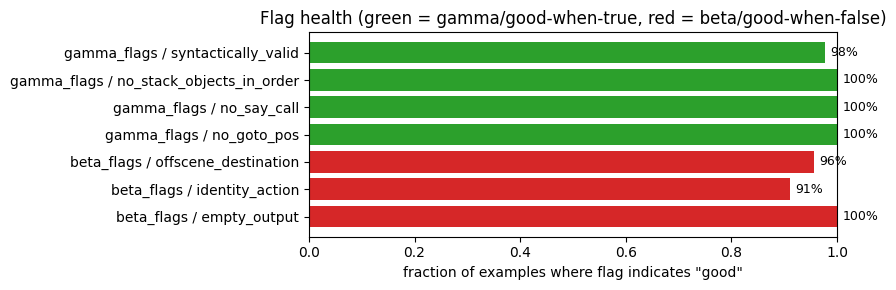

,family,flag,true_count,good_count,good_rate
0,beta_flags,empty_output,0,45,1.000000
1,beta_flags,identity_action,4,41,0.911111
2,beta_flags,offscene_destination,2,43,0.955556
3,gamma_flags,no_goto_pos,45,45,1.000000
4,gamma_flags,no_say_call,45,45,1.000000
5,gamma_flags,no_stack_objects_in_order,45,45,1.000000
6,gamma_flags,syntactically_valid,44,44,0.977778


In [3]:
flag_cols = [c for c in df.columns if c.startswith('gamma_flags.') or c.startswith('beta_flags.')]

rows = []
for c in flag_cols:
    family, name = c.split('.', 1)
    true_n = int(df[c].sum())
    # For gamma_flags, True is good. For beta_flags, True is bad (flag tripped).
    good = true_n if family == 'gamma_flags' else total - true_n
    rows.append({'family': family, 'flag': name, 'true_count': true_n, 'good_count': good, 'good_rate': good / total})
flag_df = pd.DataFrame(rows).sort_values(['family', 'flag']).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, max(3, 0.4 * len(flag_df))))
colors = ['#2ca02c' if f == 'gamma_flags' else '#d62728' for f in flag_df['family']]
ax.barh(flag_df['family'] + ' / ' + flag_df['flag'], flag_df['good_rate'], color=colors)
ax.set_xlim(0, 1.0)
ax.set_xlabel('fraction of examples where flag indicates "good"')
ax.set_title('Flag health (green = gamma/good-when-true, red = beta/good-when-false)')
for i, v in enumerate(flag_df['good_rate']):
    ax.text(v + 0.01, i, f'{v:.0%}', va='center', fontsize=9)
plt.tight_layout()
plt.show()
flag_df

## 1b. Prompt-side summary

Who are we asking the model to handle?

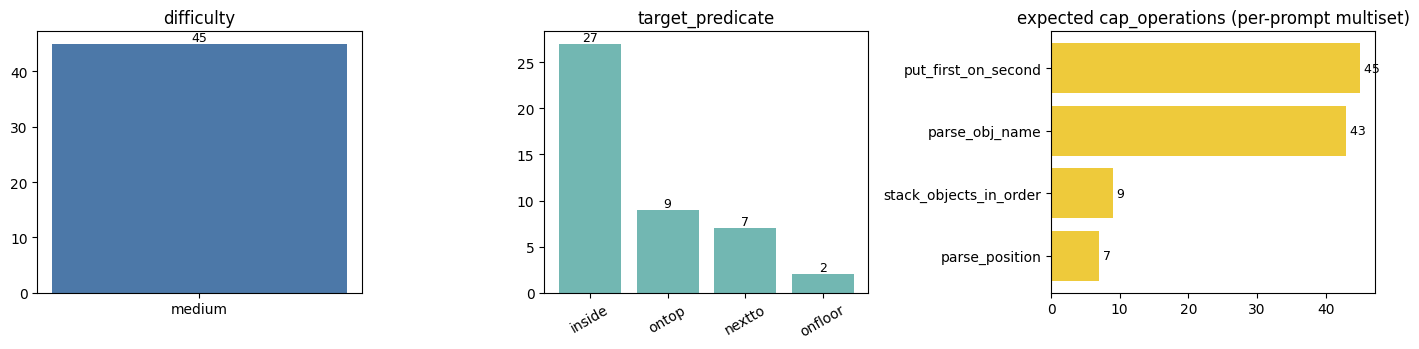

objects-per-prompt: min=3, median=6, max=6, mean=5.7


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))

diff = prompts['difficulty'].value_counts()
axes[0].bar(diff.index, diff.values, color='#4c78a8')
axes[0].set_title('difficulty')
for i, v in enumerate(diff.values):
    axes[0].text(i, v, str(v), ha='center', va='bottom', fontsize=9)

tp = prompts['target_predicate'].value_counts()
axes[1].bar(tp.index, tp.values, color='#72b7b2')
axes[1].set_title('target_predicate')
axes[1].tick_params(axis='x', rotation=30)
for i, v in enumerate(tp.values):
    axes[1].text(i, v, str(v), ha='center', va='bottom', fontsize=9)

ops = pd.Series([op for ops in prompts['cap_operations'] for op in ops]).value_counts()
axes[2].barh(ops.index[::-1], ops.values[::-1], color='#eeca3b')
axes[2].set_title('expected cap_operations (per-prompt multiset)')
for i, v in enumerate(ops.values[::-1]):
    axes[2].text(v, i, f' {v}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

obj_counts = prompts['objects'].apply(len)
print(f'objects-per-prompt: min={obj_counts.min()}, median={int(obj_counts.median())}, max={obj_counts.max()}, mean={obj_counts.mean():.1f}')

## 1c. Pass rate by prompt difficulty

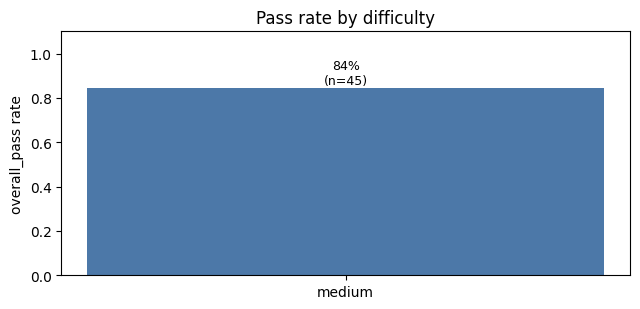

,sum,count,pass_rate
prompt.difficulty,,,
medium,38,45,0.844444


In [5]:
by_diff = df.groupby('prompt.difficulty')['overall_pass'].agg(['sum', 'count'])
by_diff['pass_rate'] = by_diff['sum'] / by_diff['count']

fig, ax = plt.subplots(figsize=(6.5, 3.2))
ax.bar(by_diff.index, by_diff['pass_rate'], color='#4c78a8')
ax.set_ylim(0, 1.1)
ax.set_ylabel('overall_pass rate')
ax.set_title('Pass rate by difficulty')
for i, (n, r) in enumerate(zip(by_diff['count'], by_diff['pass_rate'])):
    ax.text(i, r + 0.02, f'{r:.0%}\n(n={n})', ha='center', fontsize=9)
plt.tight_layout()
plt.show()
by_diff

## Failure analysis

Per-failing-id diagnosis of **why** the Ctrl-G run produced a non-pass: is the fault in the **prompt** (query/context under- or ill-specified), the **model** (bad generation despite a fine prompt), or the **DFA/checker** (flag fires on a semantically-OK output)? The `FAILURE_ANALYSIS` dict below is merged into the per-query table (§2) and the drill-down (§3).

In [6]:
# Root-cause attribution for every failing id. Each entry:
#   fault:       "prompt" | "model" | "dfa" | mix like "prompt+model"
#   root_cause:  one-line why the flag fired
#   fix:         concrete remediation (rewrite the query, widen context, tune decode, loosen DFA)
FAILURE_ANALYSIS = {
    # β offscene_destination — query names a destination ("designated area") that is
    # NOT in context_objects. Model echoed the query literally, DFA correctly flagged
    # the offscene target. Root fault is the prompt: context has only the source object
    # and no concrete destination to land on.
    'c001': {
        'fault': 'prompt',
        'root_cause': 'query references "designated area" but context_objects = [plywood] only — no real destination object to target',
        'fix': 'add a concrete destination to context (e.g. pallet, shelf, floor); OR rewrite query to name a scene object; OR wrap target in parse_position(...) and allow it in the β DFA',
    },
    'c010': {
        'fault': 'prompt',
        'root_cause': 'same shape as c001: context = [tile] only, no destination object for "designated area"',
        'fix': 'add a concrete destination to context_objects, or rewrite query to name an in-scene target (e.g. "move the tiles to the pallet")',
    },

    # β identity_action — query "put all the cartons into the carton" is self-referential.
    # Model correctly mirrors the query into put_first_on_second("carton","carton"), and
    # the DFA correctly flags src==dst. Root fault is the prompt: it is semantically ill-posed
    # when the only carton in scope is the destination.
    # Note: c018 has the SAME query but context includes [notebook, hardback, ...] — there
    # the model generalised "cartons" to other box-like items and passed. So this query
    # only fails when the context lacks plausible "carton-like" source candidates.
    'c013': {
        'fault': 'prompt',
        'root_cause': 'query is self-referential (src=dst="carton"); context = [carton, ball, plate] has no other carton-like items to generalise to',
        'fix': 'rewrite query as "put all the objects into the carton" (or "put all the items/boxes into the carton"); compare with c018 which passes because context has notebook/hardback',
    },
    'c021': {
        'fault': 'prompt',
        'root_cause': 'same self-referential query as c013; context = [carton, countertop, hamburger, fridge, apple] — none are carton-like',
        'fix': 'same as c013: rewrite query to name the source category distinct from "carton"',
    },
    'c022': {
        'fault': 'prompt',
        'root_cause': 'same self-referential query as c013; context = [carton, breakfast table, sushi, hamburger]',
        'fix': 'same as c013',
    },
    'c023': {
        'fault': 'prompt',
        'root_cause': 'same self-referential query as c013; context = [carton, chip, bottom cabinet no top]',
        'fix': 'same as c013',
    },

    # ¬γ syntactically_valid — generation truncated mid f-string
    # ("highlighter_names = parse_obj_name('the highlighters', f'"). The query itself is
    # fine and the context has plenty of objects. Fault is in the decode: the model chose
    # a multi-step parse_obj_name pattern and hit max_new_tokens before closing the string.
    'c015': {
        'fault': 'model',
        'root_cause': 'generation cut off mid f-string inside a parse_obj_name(...) call — hit max_new_tokens',
        'fix': 'raise max_new_tokens; OR bias γ DFA toward the simple put_first_on_second(...) pattern instead of parse_obj_name-then-loop; query and context are both well-formed',
    },
}


def analysis_for(row_id):
    """Lookup helper used by the table and drill-down cells below."""
    return FAILURE_ANALYSIS.get(row_id)


def analysis_html(row_id):
    a = analysis_for(row_id)
    if not a:
        return ''
    fault_color = {'prompt': '#8b4513', 'model': '#b3261e', 'dfa': '#7b1fa2'}.get(a['fault'].split('+')[0], '#444')
    return (
        f'<div style="font-size:11px;line-height:1.4">'
        f'<span style="background:#fff3e0;color:{fault_color};border-radius:6px;padding:1px 6px;'
        f'font-family:monospace;font-size:10px">fault: {a["fault"]}</span> '
        f'<span style="color:#444">{a["root_cause"]}</span>'
        f'<div style="color:#137333;margin-top:2px"><b>fix:</b> {a["fix"]}</div>'
        f'</div>'
    )

print(f'FAILURE_ANALYSIS covers {len(FAILURE_ANALYSIS)} failing ids')


FAILURE_ANALYSIS covers 7 failing ids


## 2. Per-query table

One row per example — prompt (task / difficulty / target predicate / expected CaP ops / scene objects) alongside the generated code and flag pills.

`expected ops` shows the CaP ops listed in the prompt; filled = the op appears in the generated code, muted = the op was expected but not used.

In [7]:
gamma_keys = [c.split('.', 1)[1] for c in df.columns if c.startswith('gamma_flags.')]
beta_keys  = [c.split('.', 1)[1] for c in df.columns if c.startswith('beta_flags.')]


def pill(label: str, good: bool, muted: bool = False) -> str:
    if muted:
        bg, fg = '#f1f3f4', '#5f6368'
    elif good:
        bg, fg = '#e6f4ea', '#137333'
    else:
        bg, fg = '#fce8e6', '#b3261e'
    return (f'<span style="display:inline-block;margin:1px 2px;padding:1px 6px;'
            f'border-radius:8px;font-size:11px;background:{bg};color:{fg};'
            f'font-family:monospace">{label}</span>')


def flags_cell(row) -> str:
    parts = []
    for k in gamma_keys:
        parts.append(pill(f'γ {k}', good=bool(row[f'gamma_flags.{k}'])))
    for k in beta_keys:
        parts.append(pill(f'β {k}', good=not bool(row[f'beta_flags.{k}'])))
    return ''.join(parts)


def code_cell(code: str) -> str:
    if not code:
        return '<em style="color:#888">(empty)</em>'
    return highlight(code, PythonLexer(), HtmlFormatter(nowrap=True, noclasses=True, style='friendly'))


def pass_cell(ok: bool) -> str:
    return pill('PASS' if ok else 'FAIL', good=bool(ok))


def ops_cell(expected, generated_code) -> str:
    """Pills for each expected CaP op; filled if the op name appears in generated code, muted otherwise."""
    expected = list(expected or [])
    parts = []
    for op in expected:
        used = op + '(' in (generated_code or '')
        parts.append(pill(op, good=used, muted=not used))
    return ''.join(parts) or '<em style="color:#888">—</em>'


def short_objects(objs) -> str:
    objs = list(objs or [])
    if len(objs) <= 6:
        return ', '.join(objs)
    return ', '.join(objs[:6]) + f' … (+{len(objs)-6})'


view = pd.DataFrame({
    'id':            df['id'],
    'pass':          df['overall_pass'].apply(pass_cell),
    'difficulty':    df['prompt.difficulty'],
    'task':          df['prompt.task_name'],
    'query':         df['prompt.query'],
    'target':        df['prompt.target_predicate'],
    'expected ops':  [ops_cell(e, c) for e, c in zip(df['prompt.cap_operations'], df['generated_code'])],
    'scene objects': df['prompt.objects'].apply(short_objects),
    'generated_code': df['generated_code'].fillna('').apply(code_cell),
    'flags':         df.apply(flags_cell, axis=1),
    'analysis':      df['id'].apply(analysis_html),
})

html = view.to_html(escape=False, index=False)
html = html.replace('<table ', '<table style="border-collapse:collapse;font-size:13px" ')
html = html.replace('<th>', '<th style="text-align:left;background:#f5f5f5;padding:6px;border-bottom:1px solid #ccc">')
html = html.replace('<td>', '<td style="padding:6px;border-bottom:1px solid #eee;vertical-align:top">')
display(HTML(html))

id,pass,difficulty,task,query,target,expected ops,scene objects,generated_code,flags,analysis
c001,FAIL,medium,bringing in wood,move the plywoods to the designated area,onfloor,put_first_on_second,"plywood, plywood, plywood","put_first_on_second('plywood', 'designated area')\n",γ syntactically_validγ no_goto_posγ no_say_callγ no_stack_objects_in_orderβ identity_actionβ offscene_destinationβ empty_output,"fault: prompt query references ""designated area"" but context_objects = [plywood] only — no real destination object to targetfix: add a concrete destination to context (e.g. pallet, shelf, floor); OR rewrite query to name a scene object; OR wrap target in parse_position(...) and allow it in the β DFA"
c002,PASS,medium,boxing books up for storage,put all the books inside the carton,inside,put_first_on_secondparse_obj_name,"notebook, notebook, notebook, notebook, notebook, hardback","put_first_on_second('notebook', 'carton')\nput_first_on_second('hardback', 'carton')\n",γ syntactically_validγ no_goto_posγ no_say_callγ no_stack_objects_in_orderβ identity_actionβ offscene_destinationβ empty_output,
c003,PASS,medium,cleaning out drawers,arrange the objects next to the sink,nextto,put_first_on_secondparse_obj_nameparse_position,"bowl, bowl, bottom cabinet no top, bottom cabinet no top, spoon, spoon","put_first_on_second('bowl', parse_position('a point next to the sink'))\n",γ syntactically_validγ no_goto_posγ no_say_callγ no_stack_objects_in_orderβ identity_actionβ offscene_destinationβ empty_output,
c004,PASS,medium,clearing the table after dinner,clear the table — put everything in the bucket,inside,put_first_on_secondparse_obj_name,"straight chair, straight chair, breakfast table, cup, cup, bucket","put_first_on_second('cup', 'bucket')\n",γ syntactically_validγ no_goto_posγ no_say_callγ no_stack_objects_in_orderβ identity_actionβ offscene_destinationβ empty_output,
c005,PASS,medium,collecting aluminum cans,collect all the pops and put them in the bucket,inside,put_first_on_secondparse_obj_name,"pop, pop, pop, pop, pop, pop","put_first_on_second('pop', 'bucket')\n",γ syntactically_validγ no_goto_posγ no_say_callγ no_stack_objects_in_orderβ identity_actionβ offscene_destinationβ empty_output,
c006,PASS,medium,filling an Easter basket,fill the basket with all the items on the table,inside,put_first_on_secondparse_obj_name,"basket, basket, countertop, ball, bracelet, notebook","put_first_on_second('basket', 'countertop')\n",γ syntactically_validγ no_goto_posγ no_say_callγ no_stack_objects_in_orderβ identity_actionβ offscene_destinationβ empty_output,
c007,PASS,medium,collect misplaced items,place all the misplaced items on the table,ontop,put_first_on_secondparse_obj_namestack_objects_in_order,"gym shoe, necklace, notebook, sock, sock, coffee table","put_first_on_second('gym shoe', 'coffee table')\nput_first_on_second('necklace', 'coffee table')\nput_first_on_second('notebook', 'coffee table')\nput_first_on_second('sock', 'coffee table')\n",γ syntactically_validγ no_goto_posγ no_say_callγ no_stack_objects_in_orderβ identity_actionβ offscene_destinationβ empty_output,
c008,PASS,medium,filling a Christmas stocking,fill the bottom cabinet with the objects on the table,inside,put_first_on_secondparse_obj_name,"ice cube, ice cube, ice cube, ice cube, lollipop, candy cane","put_first_on_second('ice cube', 'bottom cabinet')\nput_first_on_second('lollipop', 'bottom cabinet')\nput_first_on_second('candy cane', 'bottom cabinet')\n",γ syntactically_validγ no_goto_posγ no_say_callγ no_stack_objects_in_orderβ identity_actionβ offscene_destinationβ empty_output,
c009,PASS,medium,loading the dishwasher,put all the plates into the dishwasher,inside,put_first_on_secondparse_obj_name,"plate, plate, plate, countertop, mug, bowl","put_first_on_second('plate', 'dishwasher')\n",γ syntactically_validγ no_goto_posγ no_say_callγ no_stack_objects_in_orderβ identity_actionβ offscene_destinationβ empty_output,
c010,FAIL,medium,laying tile floors,move the tiles

## 3. Failure drill-down

Just the examples where `overall_pass` is False, with the specific flags that tripped.

In [8]:
fails = df[~df['overall_pass']].copy()
print(f'{len(fails)} failing examples')

blocks = []
for _, row in fails.iterrows():
    reasons = []
    for k in gamma_keys:
        if not bool(row[f'gamma_flags.{k}']):
            reasons.append(f'γ {k} = False')
    for k in beta_keys:
        if bool(row[f'beta_flags.{k}']):
            reasons.append(f'β {k} = True')
    err = row.get('error') or ''
    if err:
        reasons.append(f'error: {err}')
    code_html = code_cell(row['generated_code'] or '')
    ctx_line = row.get('prompt.context') or ''
    header = (
        f'{row["id"]} · {row.get("prompt.difficulty","")} '
        f'· target={row.get("prompt.target_predicate","")}'
    )
    a = analysis_for(row['id'])
    if a:
        analysis_block = (
            f'<div style="margin-top:6px;padding:6px 8px;background:#fff8e1;border-radius:4px;font-size:12px">'
            f'<div><b>fault:</b> <code>{a["fault"]}</code></div>'
            f'<div><b>why:</b> {a["root_cause"]}</div>'
            f'<div><b>fix:</b> {a["fix"]}</div>'
            f'</div>'
        )
    else:
        analysis_block = ''
    blocks.append(
        f'<div style="border:1px solid #eee;border-left:4px solid #d62728;padding:8px 12px;margin:8px 0">'
        f'<div style="font-family:monospace;color:#666">{header}</div>'
        f'<div style="font-weight:600;margin:2px 0 2px">{row.get("prompt.query", row.get("query",""))}</div>'
        f'<div style="font-size:12px;color:#444;margin-bottom:4px">task: <em>{row.get("prompt.task_name","")}</em></div>'
        f'<div style="font-size:12px;color:#444"><code>{ctx_line}</code></div>'
        f'<div style="margin:6px 0">{code_html}</div>'
        f'<div style="font-size:12px;color:#b3261e">{" · ".join(reasons) if reasons else "(no specific flag tripped)"}</div>'
        f'{analysis_block}'
        f'</div>'
    )
display(HTML(''.join(blocks)))

7 failing examples


## 4. Flag co-occurrence

How often each pair of "bad" flags fires together. Useful to spot redundant or tightly-coupled checks.

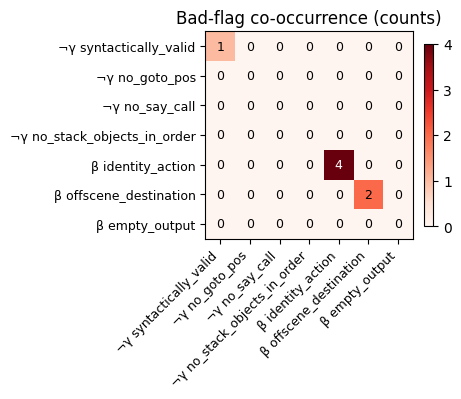

In [9]:
import numpy as np

bad_cols = {}
for k in gamma_keys:
    bad_cols[f'¬γ {k}'] = (~df[f'gamma_flags.{k}'].astype(bool)).astype(int)
for k in beta_keys:
    bad_cols[f'β {k}'] = df[f'beta_flags.{k}'].astype(bool).astype(int)
B = pd.DataFrame(bad_cols)
co = B.T.dot(B)

fig, ax = plt.subplots(figsize=(1.0 + 0.55 * len(co), 1.0 + 0.5 * len(co)))
im = ax.imshow(co.values, cmap='Reds')
ax.set_xticks(range(len(co)))
ax.set_yticks(range(len(co)))
ax.set_xticklabels(co.columns, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(co.index, fontsize=9)
for i in range(len(co)):
    for j in range(len(co)):
        ax.text(j, i, int(co.values[i, j]), ha='center', va='center',
                color='white' if co.values[i, j] > co.values.max() / 2 else 'black', fontsize=9)
ax.set_title('Bad-flag co-occurrence (counts)')
plt.colorbar(im, ax=ax, fraction=0.04)
plt.tight_layout()
plt.show()